### **Instalando Kaggle**

---
Neste bloco, estamos instalando Kaggle via 'pip'. A base de dados será incorporada da plataforma. Em máquina local, há outro comando para tal.


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Upload da Base de Dados**

---
Neste bloco, vamos "tirar o zip" da base escolhida. Fazemos o download via URL e usamos a função 'unzip'. Tenha cuidado, pois o Kaggle pode apresentar problemas de retrocompatibilidade.

In [ ]:
!kaggle datasets download -d trainingdatapro/computed-tomography-ct-of-the-brain
!unzip computed-tomography-ct-of-the-brain.zip

Dataset URL: https://www.kaggle.com/datasets/trainingdatapro/computed-tomography-ct-of-the-brain
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 66.0M/66.0M [00:00<00:00, 126MB/s]

Archive:  computed-tomography-ct-of-the-brain.zip
  inflating: ct_brain.csv            
  inflating: files/aneurysm/0.dcm    
  inflating: files/aneurysm/0.jpg    
  inflating: files/aneurysm/1.dcm    
  inflating: files/aneurysm/1.jpg    
  inflating: files/aneurysm/10.dcm   
  inflating: files/aneurysm/10.jpg   
  inflating: files/aneurysm/11.dcm   
  inflating: files/aneurysm/11.jpg   
  inflating: files/aneurysm/12.dcm   
  inflating: files/aneurysm/12.jpg   
  inflating: files/aneurysm/13.dcm   
  inflating: files/aneurysm/13.jpg   
  inflating: files/aneurysm/14.dcm   
  inflating: files/aneurysm/14.jpg   
  inflating: files/aneurysm/15.dcm   
  inflating: files/aneurysm/15.jpg   
  inflating: files/aneurysm/16.dcm   
  inflating: files/aneurysm/16.jpg   
  

### **Importação de Bibliotecas**

---
Neste ponto, fazemos a importação e definição dos pacotes necessários. Particularmente, gosto de, ao final da escrita do código, listar tudo o que foi necessário em todas as células e deixar neste bloco. Justifico como forma de deixar o código mais organizado, não necessariamente mais limpo.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

### **Definição do batch, épocas, holdouts, etc**

---
Neste bloco, faremos a configuração do set necessário para o experimento. Pode se alterar as quantidades quando necessárias. Todavia, importante lembrar que em ML, sobretudo em bases pequenas (podemos pensar em FSL), nem sempre "quanto mais, melhor". Precisamos de prudência nisto aqui, mas não precisamos nos apegar a valores-padrão (desde que devidamente justificados).

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10  # CPU-friendly
DATASET_PATH = "files"  # ajuste se necessário

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.33
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 175 images belonging to 3 classes.
Found 84 images belonging to 3 classes.


In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# congelar convoluções
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 151s 14s/step - accuracy: 0.6229 - loss: 0.9367 - val_accuracy: 0.9167 - val_loss: 0.3367
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step - accuracy: 0.9029 - loss: 0.2361 - val_accuracy: 1.0000 - val_loss: 0.1805
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step - accuracy: 0.9543 - loss: 0.1303 - val_accuracy: 1.0000 - val_loss: 0.1052
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 135s 13s/step - accuracy: 0.9714 - loss: 0.0843 - val_accuracy: 1.0000 - val_loss: 0.0777
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 141s 13s/step - accuracy: 0.9714 - loss: 0.1064 - val_accuracy: 1.0000 - val_loss: 0.0865
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 137s 13s/step - accuracy: 0.9829 - loss: 0.0528 - val_accuracy: 1.0000 - val_loss: 0.0763
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step - accuracy: 0.9886 - loss: 0.0546 - val_accuracy: 1.0000 - val_loss: 0.0476
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step - accuracy: 0.9714 - loss: 0.0647 - val_accuracy: 1.

In [ ]:
loss, acc = model.evaluate(val_generator)
print(f"Acurácia: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 44s 7s/step - accuracy: 1.0000 - loss: 0.0532
Acurácia: 1.0000


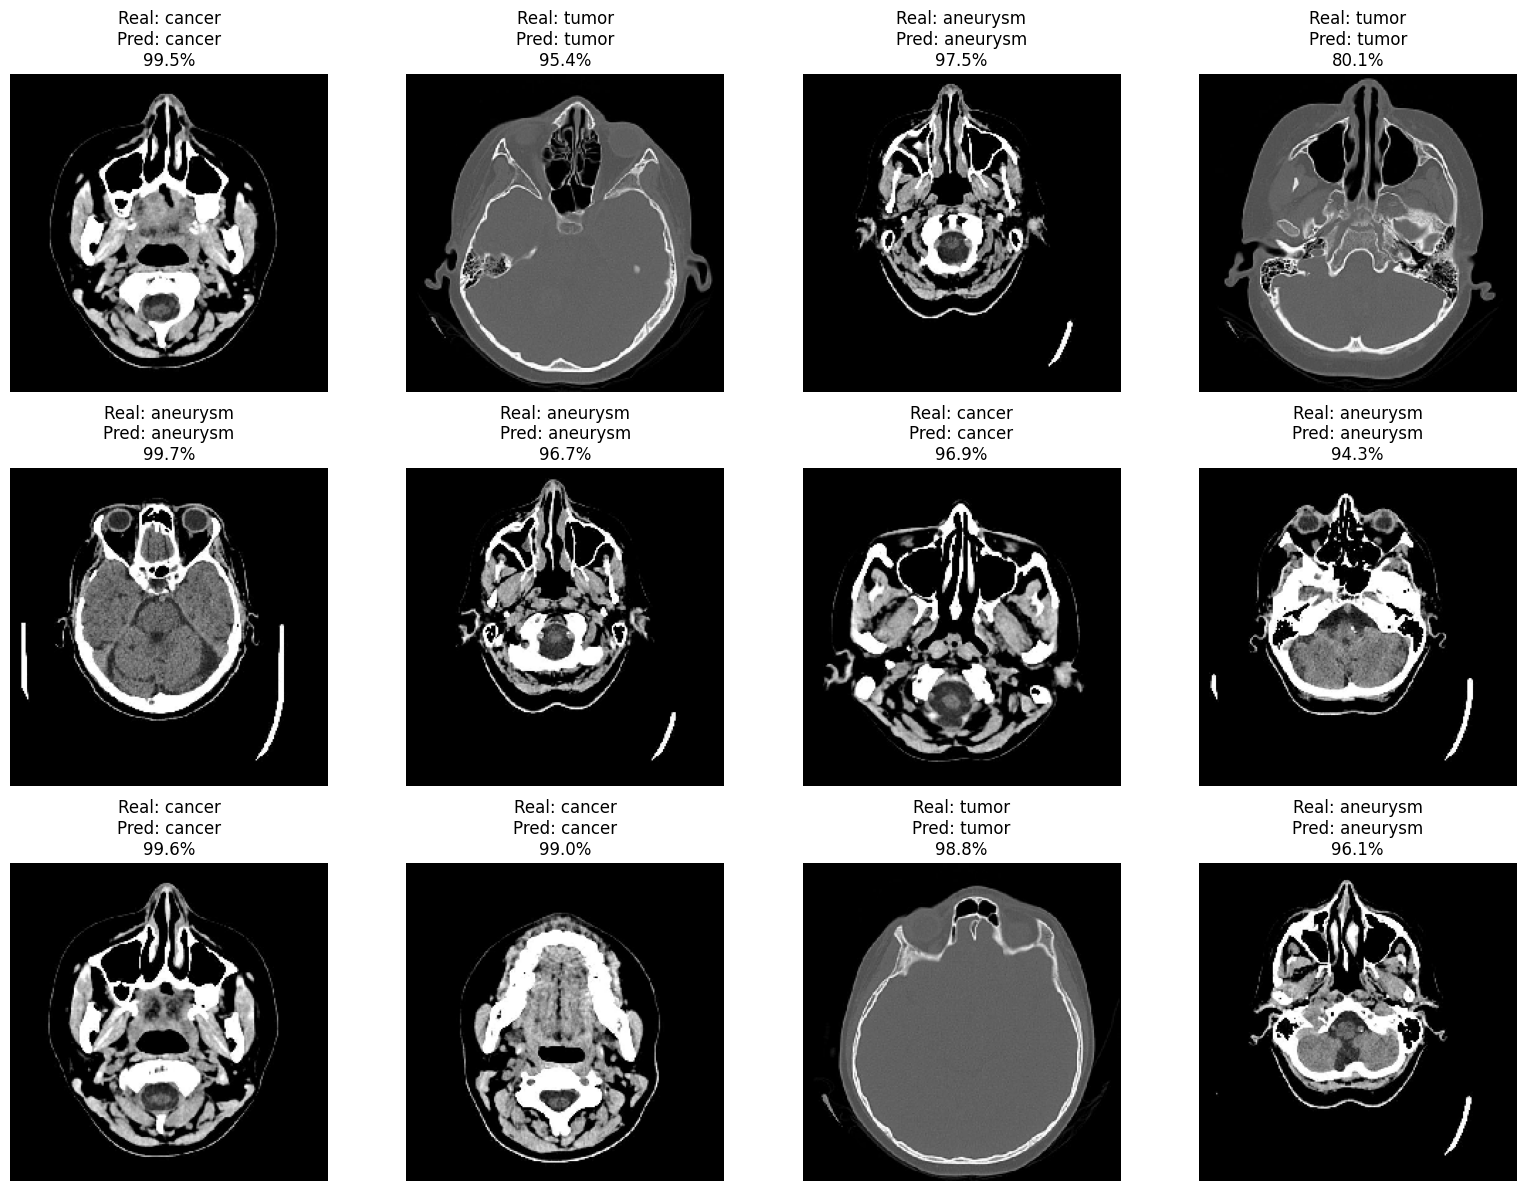

In [ ]:
N = 12  # quantas imagens você quer

cols = 4
rows = int(np.ceil(N / cols))

plt.figure(figsize=(cols * 4, rows * 4))

for i in range(N):
    plt.subplot(rows, cols, i+1)

    img = images[i]
    true_class = class_labels[np.argmax(labels[i])]

    pred_class_idx = np.argmax(predictions[i])
    pred_class = class_labels[pred_class_idx]
    confidence = np.max(predictions[i]) * 100

    plt.imshow(img)
    plt.axis('off')

    plt.title(
        f"Real: {true_class}\n"
        f"Pred: {pred_class}\n"
        f"{confidence:.1f}%"
    )

plt.tight_layout()
plt.show()

In [ ]:
errors = []

for i in range(len(images)):
    true_class = np.argmax(labels[i])
    pred_class = np.argmax(predictions[i])

    if pred_class != true_class:
        errors.append(i)

In [ ]:
N = min(6, len(errors))  # evita erro se houver poucos erros

if N == 0:
    print("Nenhum erro encontrado neste batch.")
else:
    cols = 3
    rows = int(np.ceil(N / cols))

    plt.figure(figsize=(cols * 5, rows * 5))

    for i in range(N):
        idx = errors[i]

        img = images[idx]
        true_class = class_labels[np.argmax(labels[idx])]

        pred_class_idx = np.argmax(predictions[idx])
        pred_class = class_labels[pred_class_idx]
        confidence = np.max(predictions[idx]) * 100

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')

        plt.title(
            f"Real: {true_class}\n"
            f"Pred: {pred_class}\n"
            f"{confidence:.1f}%"
        )

    plt.tight_layout()
    plt.show()

Nenhum erro encontrado neste batch.


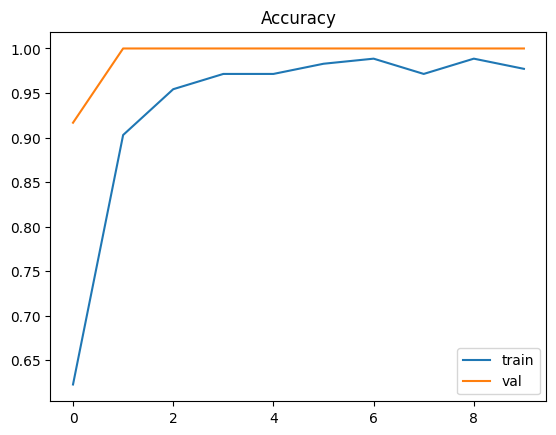

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
import tensorflow as tf
import cv2
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + (img * 255)
    superimposed_img = np.clip(superimposed_img / 255, 0, 1)

    return superimposed_img

In [ ]:
errors = []

for i in range(len(images)):
    true_class = np.argmax(labels[i])
    pred_class = np.argmax(predictions[i])

    if pred_class != true_class:
        errors.append(i)

In [ ]:
last_conv_layer_name = "block5_conv3"

In [ ]:
N = min(6, len(errors))

if N == 0:
    print("Nenhum erro neste batch.")
else:
    plt.figure(figsize=(15, 10))

    for i in range(N):
        idx = errors[i]

        img = images[idx]
        input_img = np.expand_dims(img, axis=0)

        heatmap = make_gradcam_heatmap(
            input_img,
            model,
            last_conv_layer_name
        )

        overlay = overlay_heatmap(img, heatmap)

        true_class = class_labels[np.argmax(labels[idx])]
        pred_class_idx = np.argmax(predictions[idx])
        pred_class = class_labels[pred_class_idx]
        confidence = np.max(predictions[idx]) * 100

        plt.subplot(2, 3, i+1)
        plt.imshow(overlay)
        plt.axis('off')

        plt.title(
            f"Real: {true_class}\n"
            f"Pred: {pred_class}\n"
            f"{confidence:.1f}%"
        )

    plt.tight_layout()
    plt.show()

Nenhum erro neste batch.


**Estatísticas de Imagem**

In [ ]:
import os
import pandas as pd

DATASET_PATH = "files"

data = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        data.append({
            "class": class_name,
            "path": os.path.join(class_path, img_name)
        })

df = pd.DataFrame(data)

# contagem
class_counts = df['class'].value_counts()

print(class_counts)

class
cancer      182
tumor       168
aneurysm    168
Name: count, dtype: int64


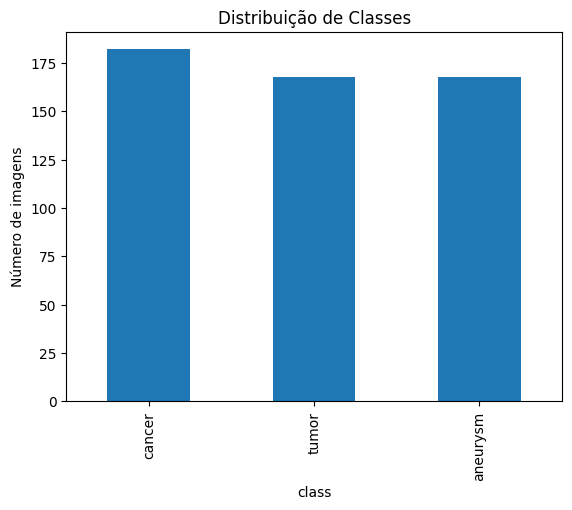

In [ ]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribuição de Classes")
plt.ylabel("Número de imagens")
plt.show()

In [ ]:
import zipfile
import cv2
import numpy as np
from tqdm import tqdm

DATASET_PATH = "computed-tomography-ct-of-the-brain.zip"

means = []
stds = []

with zipfile.ZipFile(DATASET_PATH, 'r') as z:
    file_list = [f for f in z.namelist() if f.endswith(('.jpg', '.png'))]

    for file in tqdm(file_list):
        with z.open(file) as f:
            file_bytes = np.frombuffer(f.read(), np.uint8)
            img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                means.append(np.mean(img))
                stds.append(np.std(img))

print("Média global:", np.mean(means))
print("Desvio padrão global:", np.mean(stds))

100%|██████████| 259/259 [00:01<00:00, 250.31it/s]

Média global: 50.29082935289066
Desvio padrão global: 69.16433355553482


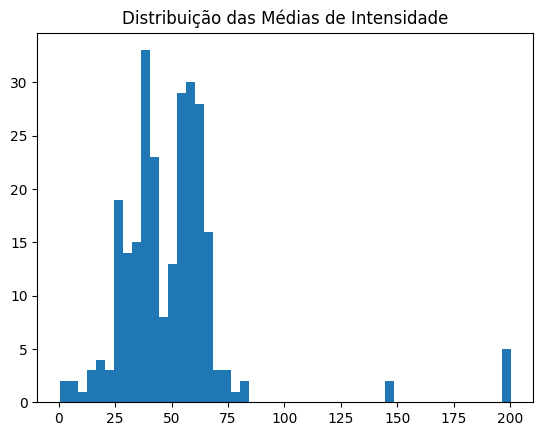

In [ ]:
plt.hist(means, bins=50)
plt.title("Distribuição das Médias de Intensidade")
plt.show()

In [ ]:
shapes = []

for path in df['path']:
    img = cv2.imread(path)
    if img is not None: # Check if image was loaded successfully
        shapes.append(img.shape)

if shapes: # Check if any shapes were collected before processing
    shapes = np.array(shapes)

    print("Altura média:", shapes[:,0].mean())
    print("Largura média:", shapes[:,1].mean())
else:
    print("No valid images found to calculate shapes.")

Altura média: 512.0
Largura média: 512.0


In [ ]:
imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 1.0833333333333333


In [ ]:
!pip install imagehash
from PIL import Image
import imagehash

hashes = {}

duplicates = []

for path in tqdm(df['path']):
    try:
        img = Image.open(path)
        h = imagehash.phash(img)

        if h in hashes:
            duplicates.append((path, hashes[h]))
        else:
            hashes[h] = path
    except:
        pass

print("Duplicatas encontradas:", len(duplicates))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.7 MB/s eta 0:00:00


100%|██████████| 518/518 [00:01<00:00, 404.50it/s]

Duplicatas encontradas: 47


In [ ]:
for i in range(min(5, len(duplicates))):
    print(duplicates[i])

('files/tumor/51.jpg', 'files/tumor/52.jpg')
('files/tumor/63.jpg', 'files/tumor/64.jpg')
('files/tumor/42.jpg', 'files/tumor/40.jpg')
('files/tumor/39.jpg', 'files/tumor/40.jpg')
('files/tumor/41.jpg', 'files/tumor/40.jpg')


In [ ]:
import os
import pandas as pd
from PIL import Image
import imagehash
from tqdm import tqdm

DATASET_PATH = "files"  # pasta já extraída

data = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        path = os.path.join(class_path, img_name)

        try:
            img = Image.open(path).convert('RGB')
            h = imagehash.phash(img)

            data.append({
                "path": path,
                "class": class_name,
                "hash": str(h)
            })
        except:
            pass

df = pd.DataFrame(data)

print("Total imagens:", len(df))
print("Hashes únicos:", df['hash'].nunique())
print("Duplicatas:", len(df) - df['hash'].nunique())

Total imagens: 259
Hashes únicos: 212
Duplicatas: 47


In [ ]:
df_clean = df.drop_duplicates(subset="hash")

print("Após remoção:", len(df_clean))

Após remoção: 212


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224)

def load_images(df):
    images = []
    labels = []

    for _, row in df.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.resize(img, IMG_SIZE)

        images.append(img)
        labels.append(row['class'])

    return np.array(images), np.array(labels)


def train_model(df_input):
    from sklearn.model_selection import train_test_split

    X, y = load_images(df_input)

    # encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    y_cat = to_categorical(y_enc)

    # split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_cat, test_size=0.33, random_state=42
    )

    # Normalize image data
    X_train = X_train / 255.0
    X_val = X_val / 255.0

    # modelo
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(len(le.classes_), activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=16,
        verbose=1
    )

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    return model, X_val, y_val, le.classes_

In [ ]:
print("\nTreinando com duplicatas...")
model_dup, X_val_dup, y_val_dup, class_names_dup = train_model(df)

print("\nTreinando sem duplicatas...")
model_clean, X_val_clean, y_val_clean, class_names_clean = train_model(df_clean)

print("\nRESULTADOS:")
print(f"Com duplicatas: {model_dup.evaluate(X_val_dup, y_val_dup, verbose=0)[1]:.4f}")
print(f"Sem duplicatas: {model_clean.evaluate(X_val_clean, y_val_clean, verbose=0)[1]:.4f}")


Treinando com duplicatas...
Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 144s 13s/step - accuracy: 0.7572 - loss: 0.5486 - val_accuracy: 0.9651 - val_loss: 0.2089
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 233s 16s/step - accuracy: 0.9884 - loss: 0.0983 - val_accuracy: 0.9767 - val_loss: 0.1041
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 173s 16s/step - accuracy: 0.9711 - loss: 0.0531 - val_accuracy: 0.9767 - val_loss: 0.0593
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 173s 16s/step - accuracy: 0.9884 - loss: 0.0336 - val_accuracy: 0.9767 - val_loss: 0.0425
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 173s 16s/step - accuracy: 0.9884 - loss: 0.0342 - val_accuracy: 0.9767 - val_loss: 0.0560

Treinando sem duplicatas...
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 117s 13s/step - accuracy: 0.7817 - loss: 0.5339 - val_accuracy: 0.9857 - val_loss: 0.1495
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 117s 13s/step - accuracy: 0.9930 - loss: 0.1018 - val_accuracy: 0.9714 - val_loss: 0.0744
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 137s 13s/step - accura

In [ ]:
# COM duplicatas
y_pred_dup = np.argmax(model_dup.predict(X_val_dup), axis=1)
y_true_dup = np.argmax(y_val_dup, axis=1)

# SEM duplicatas
y_pred_clean = np.argmax(model_clean.predict(X_val_clean), axis=1)
y_true_clean = np.argmax(y_val_clean, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 14s/step
2/3 ━━━━━━━━━━━━━━━━━━━━ 16s 17s/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 10s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names))

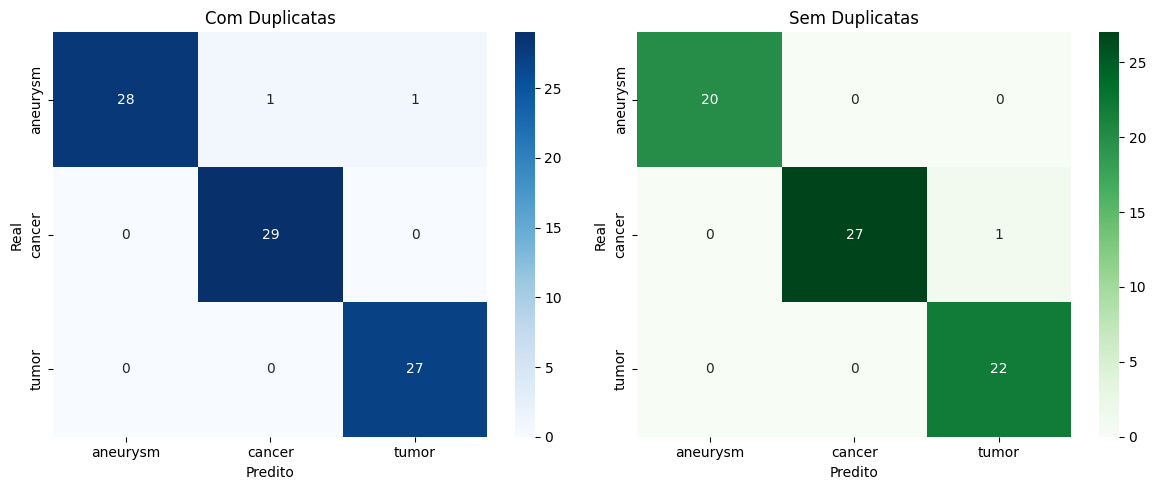

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dup = confusion_matrix(y_true_dup, y_pred_dup)
cm_clean = confusion_matrix(y_true_clean, y_pred_clean)

sns.heatmap(cm_dup, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_dup,
            yticklabels=class_names_dup,
            ax=axes[0])
axes[0].set_title("Com Duplicatas")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_clean,
            yticklabels=class_names_clean,
            ax=axes[1])
axes[1].set_title("Sem Duplicatas")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()